# 01 - Análise Exploratória (EDA)

**Objetivo:** entender os dados da máquina de café e fundamentar as decisões de modelagem.

A EDA serve a dois públicos:
- **Técnico:** justificar escolhas (sazonalidade, estacionariedade, granularidade).
- **Negócio:** gerar insights acionáveis (horário de pico, mix de produtos).

> As funções vêm de `coffee_forecast` (código de produção). O notebook narra; a lógica é testada e reutilizável.

In [1]:
from coffee_forecast.config import load_config
from coffee_forecast.data.load import load_raw
from coffee_forecast.data.preprocess import prepare, build_product_daily
from coffee_forecast import eda


cfg = load_config()
raw = load_raw(cfg, download=False)
raw.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


## 1. Qualidade dos dados

Checamos tipos, nulos e cardinalidade. Espera-se nulos apenas em `card` (compras em dinheiro), não um erro de dados.

In [2]:
eda.data_quality_report(raw)

,dtype,n_null,pct_null,n_unique
date,str,0,0.00,381
datetime,str,0,0.00,3636
cash_type,str,0,0.00,2
card,str,89,2.45,1316
money,float64,0,0.00,20
coffee_name,str,0,0.00,8


## 2. Construção da série temporal diária

Agregamos a receita e o número de transações por dia. **Decisão-chave:** reindexamos o calendário completo, preenchendo dias sem venda com 0 — caso contrário a frequência diária fica quebrada e a sazonalidade semanal é distorcida.

In [3]:
daily = prepare(raw, cfg)
print(f"Período: {daily.index.min().date()} a {daily.index.max().date()} ({len(daily)} dias)")
print(f"Receita média/dia: R$ {daily['revenue'].mean():.2f}")
print(f"Transações média/dia: {daily['transactions'].mean():.2f}")
print(f"Dias sem venda: {(daily['revenue']==0).sum()}")
daily.head()

Período: 2024-03-01 a 2025-03-23 (388 dias)
Receita média/dia: R$ 297.50
Transações média/dia: 9.37
Dias sem venda: 7


,revenue,transactions,avg_ticket,dow,day_name,month,is_weekend
date,,,,,,,
2024-03-01,396.3,11.0,36.027273,4,Friday,3,0
2024-03-02,228.1,7.0,32.585714,5,Saturday,3,1
2024-03-03,349.1,10.0,34.910000,6,Sunday,3,1
2024-03-04,135.2,4.0,33.800000,0,Monday,3,0
2024-03-05,338.5,9.0,37.611111,1,Tuesday,3,0


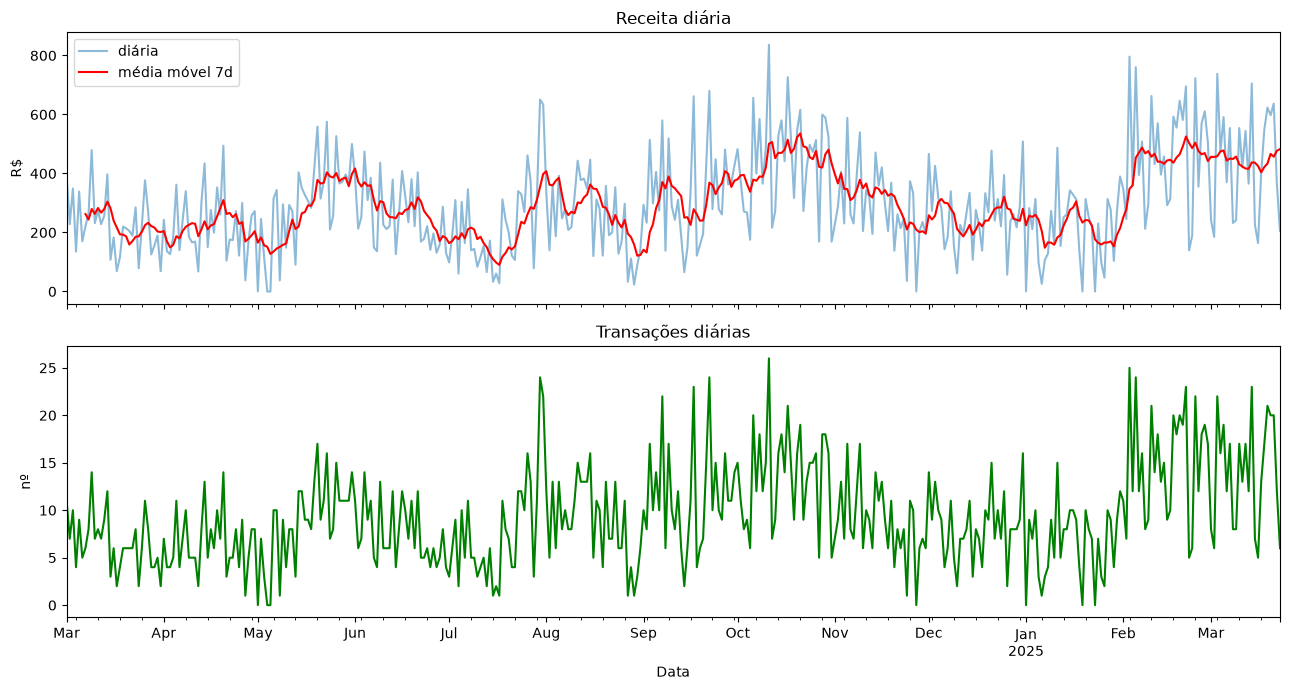

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
daily['revenue'].plot(ax=ax[0], alpha=0.5, label='diária')
daily['revenue'].rolling(7).mean().plot(ax=ax[0], color='red', label='média móvel 7d')
ax[0].set_title('Receita diária'); ax[0].set_ylabel('R$'); ax[0].legend()
daily['transactions'].plot(ax=ax[1], color='green')
ax[1].set_title('Transações diárias'); ax[1].set_ylabel('nº'); ax[1].set_xlabel('Data')
plt.tight_layout()

## 3. Sazonalidade e estacionariedade (fundamento da modelagem)

- **Decomposição STL:** separa tendência, sazonalidade semanal e resíduo.
- **Teste ADF:** avalia estacionariedade (orienta a diferenciação no SARIMA).

C:\Users\giselly_damasceno\Desktop\Nestlé\src\coffee_forecast\eda.py:48: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, pvalue, usedlag, nobs, *_ = adfuller(series.dropna())


ADF p-value: 0.0305 -> estacionária(5%): True


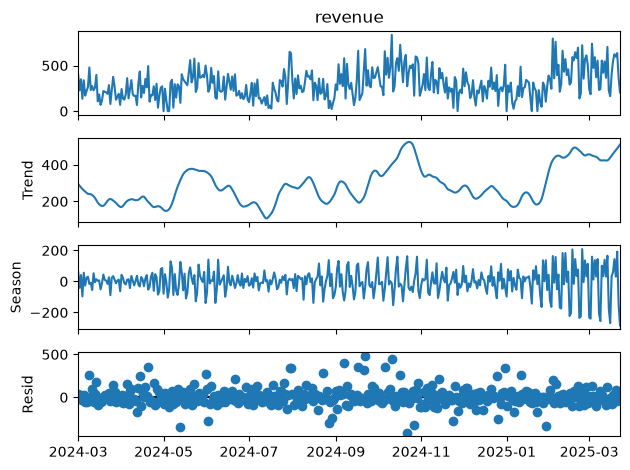

In [5]:
res = eda.stl_decompose(daily['revenue'], period=7)
res.plot()
plt.tight_layout()

adf = eda.adf_test(daily['revenue'])
print(f"ADF p-value: {adf['p_value']:.4f} -> estacionária(5%): {adf['is_stationary_5pct']}")

## 4. Padrão semanal (insight de negócio + feature)

A receita média por dia da semana confirma a sazonalidade semanal — base para o baseline Seasonal Naive e para as features de calendário.

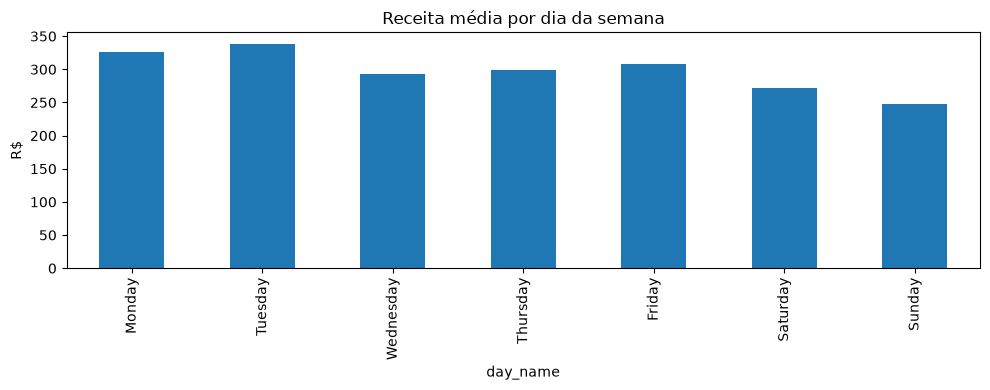

In [6]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily.groupby('day_name')['revenue'].mean().reindex(order).plot(kind='bar', figsize=(10,4), title='Receita média por dia da semana')
plt.ylabel('R$'); plt.tight_layout()

## 5. Heatmap dia da semana x hora (quando as pessoas compram)

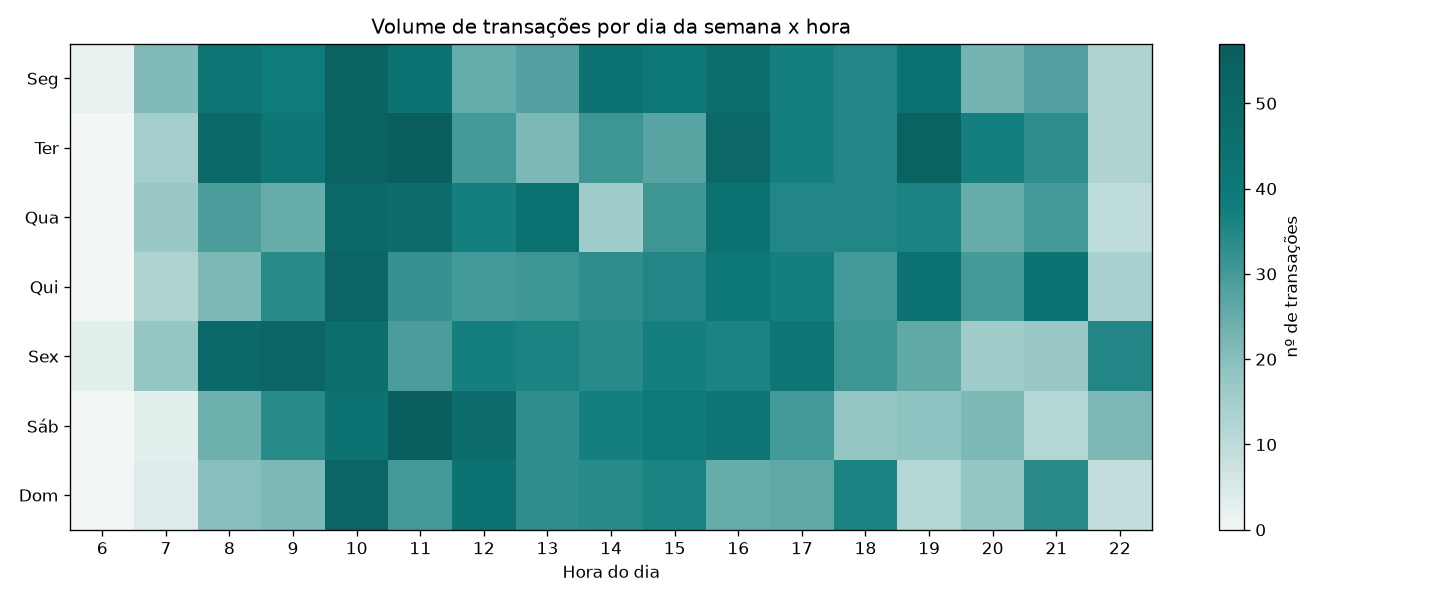

In [7]:
eda.dow_hour_heatmap(raw)
from IPython.display import Image
Image('../data/processed/figures/heatmap_dow_hour.png')

## 6. Mix de produtos (Pareto)

Poucos produtos concentram a maior parte do volume — insight direto para sortimento e reposição.

                     transactions    pct  cum_pct
coffee_name                                      
Americano with Milk           824  22.66    22.66
Latte                         782  21.51    44.17
Americano                     578  15.90    60.07
Cappuccino                    501  13.78    73.85
Cortado                       292   8.03    81.88
Hot Chocolate                 282   7.76    89.64
Cocoa                         243   6.68    96.32
Espresso                      134   3.69   100.01


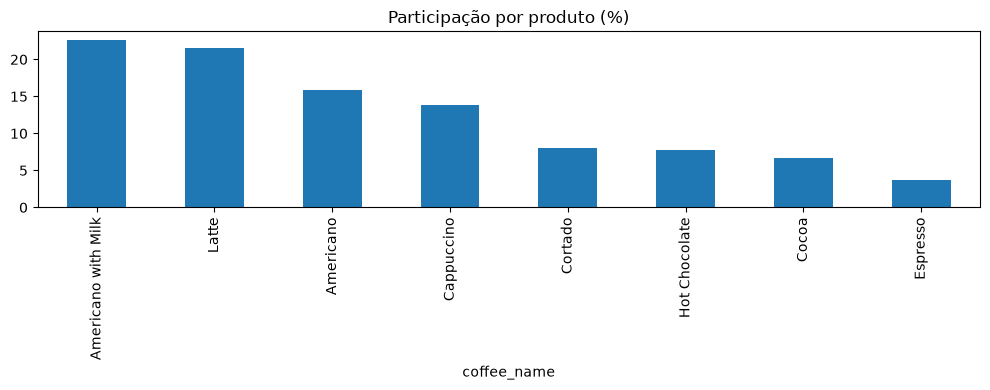

In [8]:
pareto = eda.product_pareto(raw, cfg.target.product_col)
print(pareto)
pareto['pct'].plot(kind='bar', figsize=(10,4), title='Participação por produto (%)')
plt.tight_layout()

## Conclusões da EDA

1. **Volume baixo** (~9-10 vendas/dia) -> previsão no **agregado diário** (receita), não por produto/dia (ruído domina).
2. **Sazonalidade semanal clara** -> justifica Seasonal Naive como baseline e features de calendário.
3. **Série estacionária** (ADF) -> orienta ordens do SARIMA.
4. **Mix concentrado** (2 produtos = ~44%) -> insight de negócio para sortimento.

Próximo passo: `02_modeling.ipynb`.